In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv(r"C:\Users\Poonguzhali\OneDrive\Attachments\Desktop\ai_job_dataset.csv")

In [10]:
df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null  object 
 7   company_size            15000 non-null  object 
 8   employee_residence      15000 non-null  object 
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  object 
 11  education_required      15000 non-null  object 
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  object 
 14  posting_date            15000 non-null

In [12]:
df.isnull().sum()

job_id                    0
job_title                 0
salary_usd                0
salary_currency           0
experience_level          0
employment_type           0
company_location          0
company_size              0
employee_residence        0
remote_ratio              0
required_skills           0
education_required        0
years_experience          0
industry                  0
posting_date              0
application_deadline      0
job_description_length    0
benefits_score            0
company_name              0
dtype: int64

In [13]:
df = df.drop_duplicates()

In [14]:
df.describe()

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,115348.965133,49.483333,6.253200,1503.314733,7.504273
std,60260.940438,40.812712,5.545768,576.127083,1.450870
min,32519.000000,0.000000,0.000000,500.000000,5.000000
25%,70179.750000,0.000000,2.000000,1003.750000,6.200000
50%,99705.000000,50.000000,5.000000,1512.000000,7.500000
75%,146408.500000,100.000000,10.000000,2000.000000,8.800000
max,399095.000000,100.000000,19.000000,2499.000000,10.000000


In [16]:
numeric_cols = ['salary_usd']


In [17]:
df[numeric_cols].mean()

salary_usd    115348.965133
dtype: float64

In [18]:
numeric_cols =['remote_ratio']


In [19]:
df[numeric_cols].median()

remote_ratio    50.0
dtype: float64

In [21]:
numeric_cols = ['years_experience']

In [22]:
df[numeric_cols].std()

years_experience    5.545768
dtype: float64

In [23]:
numeric_cols = ['salary_usd',
                'remote_ratio',
                'years_experience',
                'job_description_length',
                'benefits_score']


In [24]:
df[numeric_cols].quantile([0.25, 0.50, 0.75])

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score
0.25,70179.75,0.0,2.0,1003.75,6.2
0.50,99705.00,50.0,5.0,1512.00,7.5
0.75,146408.50,100.0,10.0,2000.00,8.8


In [25]:
df[numeric_cols].quantile([0.10, 0.90, 0.95])

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score
0.10,53087.60,0.0,0.0,704.0,5.5
0.90,199217.20,100.0,15.0,2296.0,9.5
0.95,237987.95,100.0,17.0,2402.0,9.8


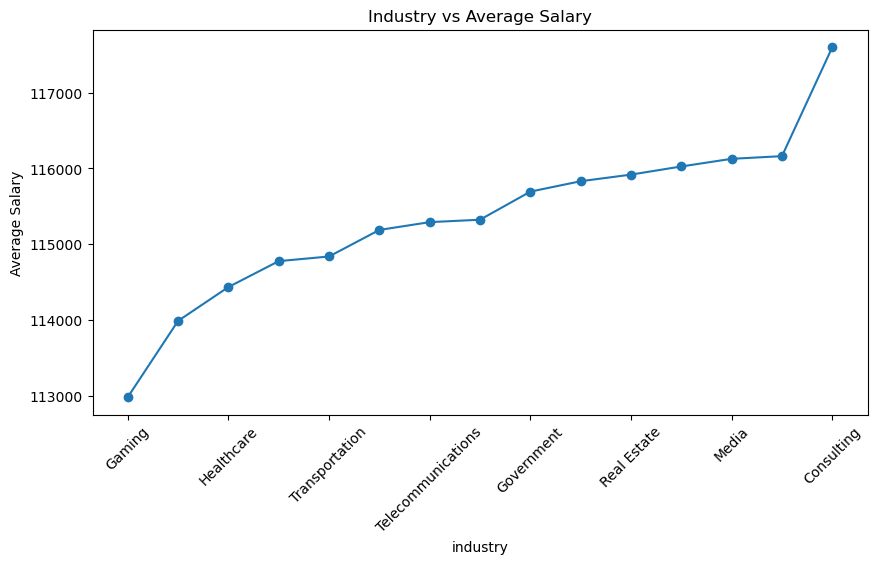

In [26]:
industry_salary = df.groupby('industry')['salary_usd'].mean().sort_values()

plt.figure(figsize=(10,5))
industry_salary.plot(kind='line', marker='o')
plt.title("Industry vs Average Salary")
plt.ylabel("Average Salary")
plt.xticks(rotation=45)
plt.show()

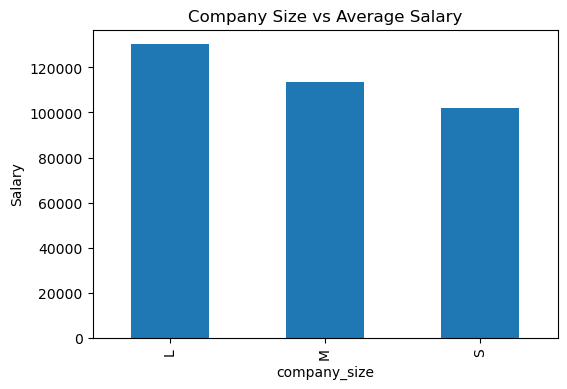

In [27]:
company_salary = df.groupby('company_size')['salary_usd'].mean()

plt.figure(figsize=(6,4))
company_salary.plot(kind='bar')
plt.title("Company Size vs Average Salary")
plt.ylabel("Salary")
plt.show()

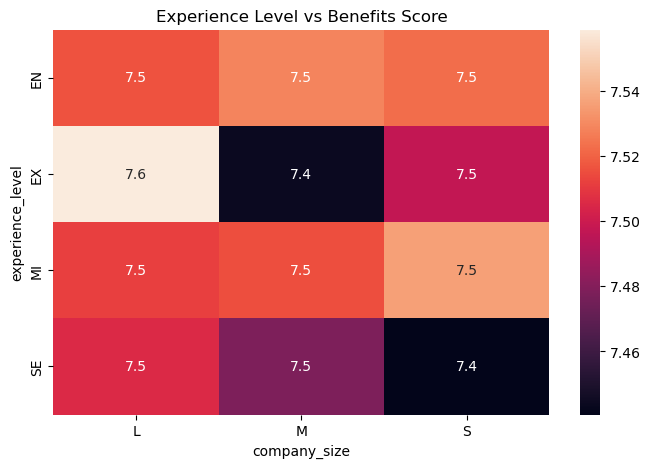

In [28]:
heat_data = pd.pivot_table(
    df,
    values='benefits_score',
    index='experience_level',
    columns='company_size',
    aggfunc='mean'
)

plt.figure(figsize=(8,5))
sns.heatmap(heat_data, annot=True)
plt.title("Experience Level vs Benefits Score")
plt.show()

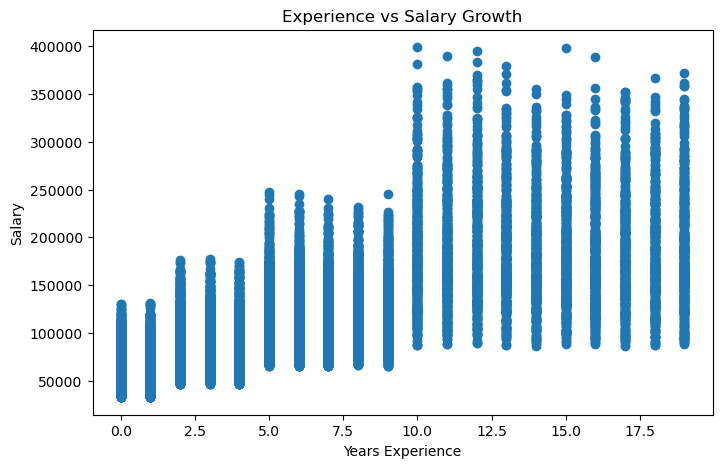

In [29]:
plt.figure(figsize=(8,5))
plt.scatter(df['years_experience'],
            df['salary_usd'])

plt.xlabel("Years Experience")
plt.ylabel("Salary")
plt.title("Experience vs Salary Growth")
plt.show()

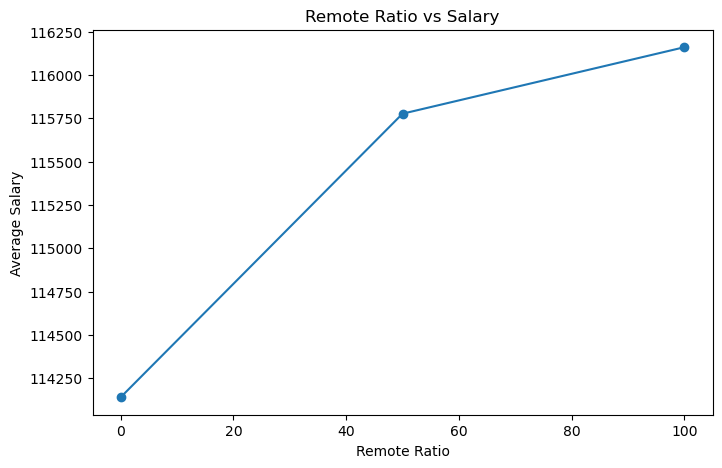

In [30]:
remote_salary = df.groupby('remote_ratio')['salary_usd'].mean()

plt.figure(figsize=(8,5))
plt.plot(remote_salary.index,
         remote_salary.values,
         marker='o')

plt.xlabel("Remote Ratio")
plt.ylabel("Average Salary")
plt.title("Remote Ratio vs Salary")
plt.show()

In [31]:
df[['years_experience','salary_usd']].corr()

,years_experience,salary_usd
years_experience,1.000000,0.737556
salary_usd,0.737556,1.000000


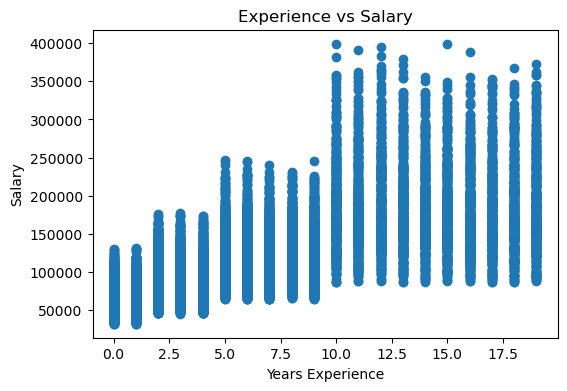

In [32]:
plt.figure(figsize=(6,4))
plt.scatter(df['years_experience'],
            df['salary_usd'])

plt.xlabel("Years Experience")
plt.ylabel("Salary")
plt.title("Experience vs Salary")
plt.show()

In [33]:
df[['benefits_score','salary_usd']].corr()

,benefits_score,salary_usd
benefits_score,1.000000,0.000985
salary_usd,0.000985,1.000000


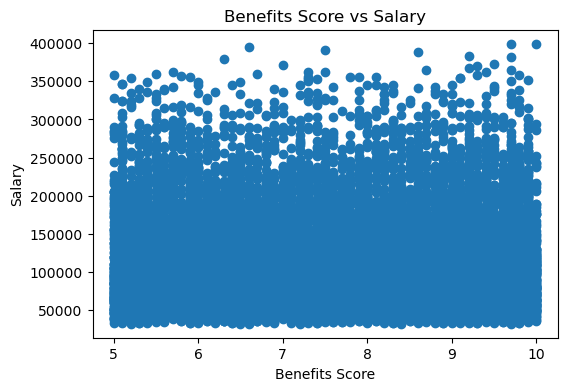

In [34]:
plt.figure(figsize=(6,4))
plt.scatter(df['benefits_score'],
            df['salary_usd'])

plt.xlabel("Benefits Score")
plt.ylabel("Salary")
plt.title("Benefits Score vs Salary")
plt.show()

In [37]:
size_map = {
    'S':1,
    'M':2,
    'L':3
}

df['company_size_num'] = df['company_size'].map(size_map)

In [38]:
df[['company_size_num',
    'years_experience']].corr()

,company_size_num,years_experience
company_size_num,1.000000,-0.007768
years_experience,-0.007768,1.000000


In [39]:
size_map = {
    'S':1,
    'M':2,
    'L':3
}

df['company_size_num'] = df['company_size'].map(size_map)

corr = df[['salary_usd',
           'years_experience',
           'remote_ratio',
           'job_description_length',
           'benefits_score',
           'company_size_num']].corr()

print(corr)

                        salary_usd  years_experience  remote_ratio  \
salary_usd                1.000000          0.737556      0.013727   
years_experience          0.737556          1.000000      0.015321   
remote_ratio              0.013727          0.015321      1.000000   
job_description_length   -0.009092         -0.007526      0.004475   
benefits_score            0.000985         -0.007275      0.003139   
company_size_num          0.190923         -0.007768      0.002991   

                        job_description_length  benefits_score  \
salary_usd                           -0.009092        0.000985   
years_experience                     -0.007526       -0.007275   
remote_ratio                          0.004475        0.003139   
job_description_length                1.000000        0.006744   
benefits_score                        0.006744        1.000000   
company_size_num                      0.007042        0.006506   

                        company_size_num  
sal

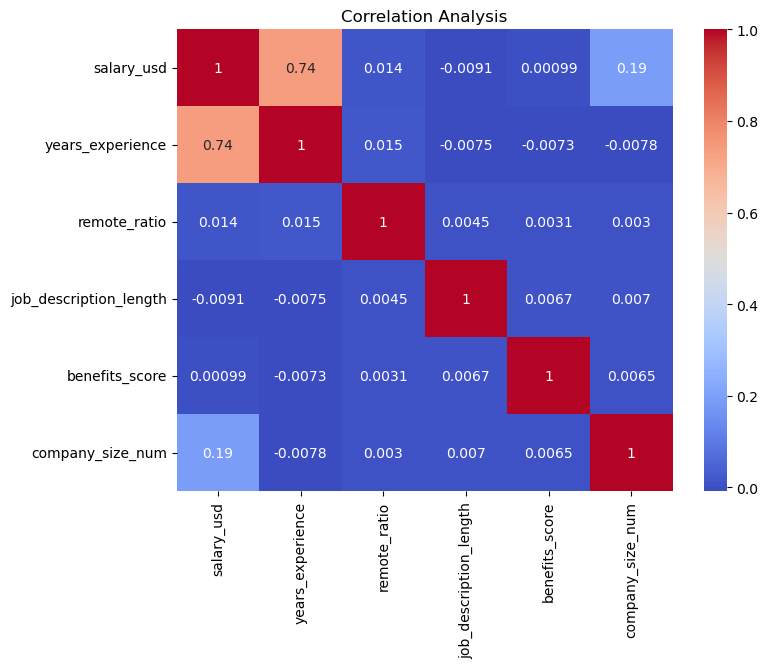

In [40]:
plt.figure(figsize=(8,6))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Analysis")
plt.show()

In [41]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [42]:
from scipy.stats import f_oneway

small = df[df['company_size']=='S']['salary_usd']
medium = df[df['company_size']=='M']['salary_usd']
large = df[df['company_size']=='L']['salary_usd']

f_stat, p_value = f_oneway(small, medium, large)

print("F-Statistic =", f_stat)
print("P-Value =", p_value)

F-Statistic = 287.10387515940585
P-Value = 4.366865535018369e-123


In [43]:
if p_value < 0.05:
    print("Reject Null Hypothesis")
    print("Company size significantly impacts salary")
else:
    print("Fail to Reject Null Hypothesis")
    print("Company size does not significantly impact salary")

Reject Null Hypothesis
Company size significantly impacts salary


In [44]:
def salary_category(salary):

    if salary >= 150000:
        return "High Salary Organization"

    elif salary >= 80000:
        return "Medium Salary Organization"

    else:
        return "Low Salary Organization"

df['Organization_Category'] = df['salary_usd'].apply(salary_category)

In [45]:
df['Organization_Category'].value_counts()

Organization_Category
Medium Salary Organization    6466
Low Salary Organization       5007
High Salary Organization      3527
Name: count, dtype: int64

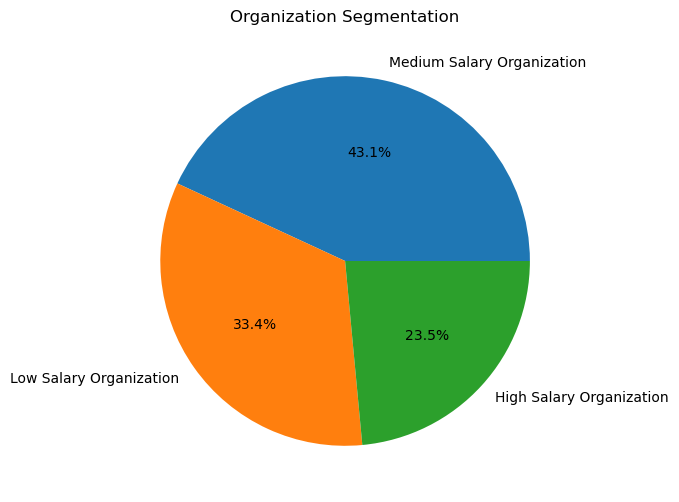

In [46]:
plt.figure(figsize=(6,6))

df['Organization_Category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Organization Segmentation")
plt.ylabel("")
plt.show()

In [47]:
df.groupby('Organization_Category')['salary_usd'].mean()

Organization_Category
High Salary Organization      204054.530196
Low Salary Organization        60389.601558
Medium Salary Organization    109521.097123
Name: salary_usd, dtype: float64

In [48]:
df.groupby('Organization_Category')['benefits_score'].mean()

Organization_Category
High Salary Organization      7.504820
Low Salary Organization       7.526703
Medium Salary Organization    7.486607
Name: benefits_score, dtype: float64

In [49]:
df.groupby('Organization_Category')['years_experience'].mean()

Organization_Category
High Salary Organization      12.434080
Low Salary Organization        1.742960
Medium Salary Organization     6.374265
Name: years_experience, dtype: float64

In [ ]:
df.groupby('Organization_Category')[[
    'salary_usd',
    'benefits_score',
    'years_experience'
]].mean()

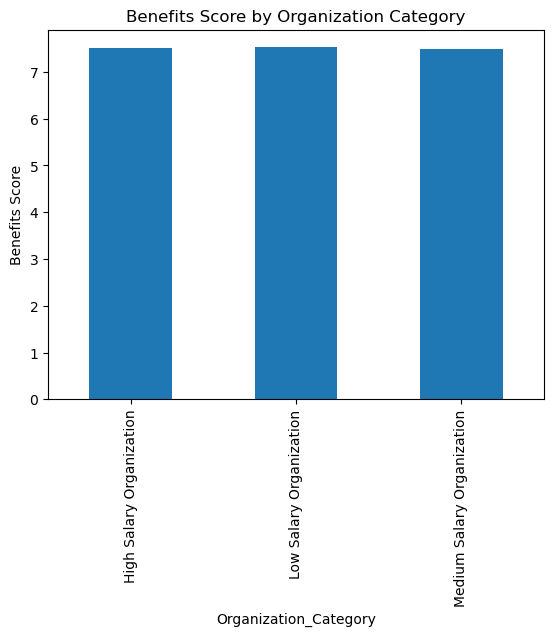

In [50]:
seg = df.groupby('Organization_Category')[
    'benefits_score'
].mean()

seg.plot(kind='bar')

plt.title("Benefits Score by Organization Category")
plt.ylabel("Benefits Score")
plt.show()